In [1]:
!pip install --upgrade bambi
!pip uninstall -y arviz
!pip install arviz==0.16.1

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
  Using cached http://mirrors.aliyun.com/pypi/packages/95/97/af3c62d325ce05cf8aa8dea095de5dde683afa41fd064a4d4679c2a85c09/arviz-0.15.1-py3-none-any.whl (1.6 MB)
Found existing installation: arviz 0.15.1
Uninstalling arviz-0.15.1:
  Successfully uninstalled arviz-0.15.1
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Processing ./arviz-0.16.1-py3-none-any.whl
INFO: pip is looking at multiple versions of arviz to determine which version is compatible with other requirements. This could take a while.
ERROR: Package 'arviz' requires a different Python: 3.8.10 not in '>=3.9'


In [4]:
import arviz as az
az.__version__

'0.15.1'

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
 
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.utils.class_weight import compute_class_weight

import bambi as bmb
import pickle

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [8]:
train_filename = "../data/training1109.xlsx"
save_dir="./dist"

## Read Data

In [7]:
def readExcel(filename, sheet_name="Sheet1", usecols=None):
    df=pd.read_excel(io=filename,sheet_name=sheet_name, usecols=usecols)
    nullIndexs = np.where((df.isnull()).values)
    return df.values, list(df.columns), nullIndexs


def getFeatures(values, headers, usedHeaders=None, dtype="float32"):
    if usedHeaders is None:
        return values
    usedHeaderIndexs = [headers.index(h) for h in usedHeaders]
    data = np.array(values[:,usedHeaderIndexs], dtype=dtype)
    return data

def getLabels(values, headers, labelHeader=None, dtype="int"):
    if labelHeader is None:
         raise Exception(f"必须指定labelHeader参数")
    labelHeaderIdx = headers.index(labelHeader)
    labels = np.array(values[:,labelHeaderIdx], dtype=dtype)
    return labels 

In [9]:
values, headers, nullIndexs = readExcel(train_filename)
rmRowIndexs = list(set(list(nullIndexs[0])))
print(len(rmRowIndexs))

128


In [10]:
all_labels = getLabels(values, headers, labelHeader="ssi.bin", dtype="int")
all_labels = np.delete(all_labels,rmRowIndexs,0)
print(all_labels.shape, all_labels.dtype)
print(all_labels)

(2369,) int64
[0 0 0 ... 0 0 0]


In [11]:
# 全部变量
usedHeaders = ["sex","age","height","weight","bmi","smoke",
               "hp","dm","chd","arrhy","copd","pad","rf","chemo",
               "radio","pn","picc","sbp.pre","dbp.pre","hr.pre",
               "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
               "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
               "alt.pre","alt.post","scr.pre","scr.post","asa","bleed",
               "trans.surg","trans.post","icu","los.icu","scopy","open",
               "scopy.open","stoma","class.surg.t1"
              ]

# 筛选的连续变量
headers_1 = ["sex","age","height","weight","bmi","bleed","trans.surg","trans.post"]

# 筛选的分类变量
headers_2 = ["smoke","hp","dm","chd","arrhy","copd","pad",
             "rf","chemo","radio","pn","picc","asa","icu","los.icu",
             "scopy","open","scopy.open","stoma","class.surg.t1"
            ]
             
# 筛选的术前术后变量
headers_3 = ["sbp.pre","dbp.pre","hr.pre",
             "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
             "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
             "alt.pre","alt.post","scr.pre","scr.post"
            ]

print(len(headers_1)+len(headers_2)+len(headers_3)==len(usedHeaders))

True


In [12]:
dtype = "float64"
all_features = getFeatures(values, headers, usedHeaders=usedHeaders, dtype=dtype)
all_features = np.delete(all_features,rmRowIndexs,0)
print(all_features.shape, all_features.dtype)
print(all_features)

(2369, 45) float64
[[ 1.   63.    1.59 ...  0.    0.    2.  ]
 [ 0.   21.    1.65 ...  0.    0.    3.  ]
 [ 1.   57.    1.78 ...  1.    0.    1.  ]
 ...
 [ 0.   59.    1.6  ...  0.    0.    1.  ]
 [ 0.   63.    1.58 ...  0.    0.    2.  ]
 [ 1.   58.    1.72 ...  0.    0.    2.  ]]


### 变量处理

In [13]:
"""
ctype:
  - both 取术前和术后
  - pre 只取术前
  - post 只取术后
  - rate 术后/术前
  - change 术后-术前
  - ratio (术后-术前)/术前 * 100
islog 是否取对数
"""
def calcPrePost(features, ctype="post", islog=False):
    pre = features[:,0]
    post = features[:,1]
    res=None
    if ctype=="both":
        res = np.empty((features.shape[0],2))
        res[:,0]=pre
        res[:,1]=post
    elif ctype=="pre":
        res = pre
        res = res.reshape((-1,1))
    elif ctype=="post":
        res = post
        res = res.reshape((-1,1))
    elif ctype=="rate":
        res = post/pre
        res = res.reshape((-1,1))
    elif ctype=="change":
        res = post-pre
        res = res.reshape((-1,1))
    elif ctype=="ratio":
        res = 100* (post-pre)/pre
        res = res.reshape((-1,1))
    else:
        res = features
    
    return np.log(res) if islog else res

In [14]:
var_one = [
    {"key":"copd","rename":"Copd"},
    {"key":"pad", "rename":"pad"},
    {"key":"picc","rename":"picc"},
    {"key":"icu","rename":"icu"},
    {"key":"los.icu","rename":"icuG1"},
    {"key":"scopy.open","rename":"scopy2open"},
    {"key":"stoma","rename":"stoma"},
    {"key":"class.surg.t1","rename":"surgClass"},
    {"key":"bleed","func":lambda fea: 1*(fea>500),"rename":"bleedG500"},
    {"key":"weight","rename":"weight"}
]
var_pre_post = [
    {"pre":"wbc.pre","post":"wbc.post","ctype":"post","islog":True,"rename":"WBCPost"},
    {"pre":"plt.pre","post":"plt.post","ctype":"change","islog":False,"rename":"PltChange"},
    {"pre":"hb.pre","post":"hb.post","ctype":"change","islog":False,"rename":"HbChange"},
    {"pre":"alb.pre","post":"alb.post","ctype":"post","islog":False,"rename":"AlbPost"},
    {"pre":"alt.pre","post":"alt.post","ctype":"rate","islog":True,"rename":"AltRate"},
    {"pre":"scr.pre","post":"scr.post","ctype":"rate","islog":False,"rename":"ScrRate"},
]

In [15]:
fea_1 = None
fea_1_names = []
for pair in var_pre_post:
    fea = calcPrePost(
        all_features[:,[usedHeaders.index(pair["pre"]), usedHeaders.index(pair["post"])]], 
        ctype=pair["ctype"],
        islog=pair["islog"]
    )
    fea_1 = fea if fea_1 is None else np.concatenate([fea_1,fea],axis=1)
    fea_1_names.append(pair["rename"])

In [16]:
fea_2 = None
fea_2_names = []
for key_func in var_one:
    if not "func" in key_func:
        fea = all_features[:,usedHeaders.index(key_func["key"])].reshape((-1,1))
    else:
        key = key_func["key"]
        func = key_func["func"]
        fea = all_features[:,usedHeaders.index(key)]
        fea = func(fea).reshape((-1,1))
    fea_2 = fea if fea_2 is None else np.concatenate([fea_2,fea],axis=1)
    fea_2_names.append(key_func["rename"])

### Split Data

In [17]:
from sklearn.model_selection import train_test_split
test_size=0.3
all_selected_features = np.concatenate([fea_1,fea_2],axis=1)
all_selected_fea_nams = fea_1_names + fea_2_names
train_features, test_features, train_labels, test_labels = train_test_split(all_selected_features, all_labels, test_size=test_size, random_state=123, stratify=all_labels)
print(train_features.shape, test_features.shape, train_labels.shape, test_labels.shape)

(1658, 16) (711, 16) (1658,) (711,)


In [19]:
scaler = StandardScaler()
scaler.fit(train_features)
train_features_s = scaler.transform(train_features)
test_features_s = scaler.transform(test_features)

# GLM

In [20]:
train_values = dict()
for i in range(len(all_selected_fea_nams)):
    key_name = all_selected_fea_nams[i]
    train_values[key_name] = train_features_s[:,i]
train_values["osssi"] =  train_labels
train_data = pd.DataFrame(train_values)

In [21]:
test_values = dict()
for i in range(len(all_selected_fea_nams)):
    key_name = all_selected_fea_nams[i]
    test_values[key_name] = test_features_s[:,i]

test_data = pd.DataFrame(test_values)

In [22]:
train_data

,WBCPost,PltChange,HbChange,AlbPost,AltRate,ScrRate,Copd,pad,picc,icu,icuG1,scopy2open,stoma,surgClass,bleedG500,weight,osssi
0,-0.590793,1.236638,1.725087,-0.507662,1.169200,0.236707,-0.208383,-0.374570,1.666363,-0.478601,-0.242381,-0.233896,-0.444946,0.768633,-0.569457,-1.428675,0
1,0.773908,-0.175127,1.067000,0.540276,1.496083,-0.469838,-0.208383,-0.374570,-0.600109,2.089425,4.125741,-0.233896,-0.444946,-1.295162,-0.569457,0.379026,0
2,-0.372902,0.542327,1.798208,0.121101,-0.187645,0.048994,-0.208383,-0.374570,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-1.295162,-0.569457,1.239836,0
3,0.047353,0.449752,0.262670,0.749864,0.132455,-0.038641,-0.208383,-0.374570,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-0.263265,-0.569457,-0.223541,0
4,0.846627,0.472896,-0.468538,0.330688,2.594392,0.458505,-0.208383,-0.374570,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-1.295162,-0.569457,-0.309622,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1653,0.470678,-0.938869,-0.029813,-0.298075,0.096946,0.166614,-0.208383,-0.374570,1.666363,-0.478601,-0.242381,-0.233896,-0.444946,0.768633,-0.569457,-0.826108,0
1654,0.029588,-0.267702,-0.102934,0.540276,-0.774102,-0.608362,-0.208383,-0.374570,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-0.263265,-0.569457,1.584160,0
1655,-1.717148,-1.147162,-0.980384,-0.088487,-0.841322,-0.336011,-0.208383,2.669729,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-0.263265,1.756059,1.067674,0
1656,0.842847,-0.545426,2.456295,0.959451,0.564146,-0.019017,-0.208383,-0.374570,-0.600109,-0.478601,-0.242381,-0.233896,-0.444946,-1.295162,-0.569457,-1.084351,0


In [23]:
strpa = "osssi ~ "
i=0
for nam in all_selected_fea_nams:
    strpa+= nam
    if i<len(all_selected_fea_nams)-1:
        strpa+= " + "
    i+=1
print(strpa)
model = bmb.Model(strpa, train_data, family="bernoulli", link="logit")
model_fitted = model.fit(
    draws=10000, tune=2000, discard_tuned_samples=True, chains=2, random_seed=123
)

osssi ~ WBCPost + PltChange + HbChange + AlbPost + AltRate + ScrRate + Copd + pad + picc + icu + icuG1 + scopy2open + stoma + surgClass + bleedG500 + weight


Modeling the probability that osssi==1
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [Intercept, WBCPost, PltChange, HbChange, AlbPost, AltRate, ScrRate, Copd, pad, picc, icu, icuG1, scopy2open, stoma, surgClass, bleedG500, weight]


Sampling 2 chains for 2_000 tune and 10_000 draw iterations (4_000 + 20_000 draws total) took 310 seconds.


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3398, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_6130/750983663.py", line 10, in <cell line: 10>
    model_fitted = model.fit(
  File "/root/miniconda3/lib/python3.8/site-packages/bambi/models.py", line 333, in fit
    return self.backend.run(
  File "/root/miniconda3/lib/python3.8/site-packages/bambi/backend/pymc.py", line 96, in run
    result = self._run_mcmc(
  File "/root/miniconda3/lib/python3.8/site-packages/bambi/backend/pymc.py", line 172, in _run_mcmc
    idata = pm.sample(
  File "/root/miniconda3/lib/python3.8/site-packages/pymc/sampling/mcmc.py", line 791, in sample
    return _sample_return(
  File "/root/miniconda3/lib/python3.8/site-packages/pymc/sampling/mcmc.py", line 859, in _sample_return
    idata = pm.to_inference_data(mtrace, **ikwargs)
  File "/root/miniconda3/lib/python3.8/site-packages/pym

In [2]:
model.plot_priors()

NameError: name 'model' is not defined

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'WBCPost'}>,
        <Axes: title={'center': 'WBCPost'}>],
       [<Axes: title={'center': 'PltChange'}>,
        <Axes: title={'center': 'PltChange'}>],
       [<Axes: title={'center': 'HbChange'}>,
        <Axes: title={'center': 'HbChange'}>],
       [<Axes: title={'center': 'AlbPost'}>,
        <Axes: title={'center': 'AlbPost'}>],
       [<Axes: title={'center': 'AltRate'}>,
        <Axes: title={'center': 'AltRate'}>],
       [<Axes: title={'center': 'ScrRate'}>,
        <Axes: title={'center': 'ScrRate'}>],
       [<Axes: title={'center': 'Copd'}>,
        <Axes: title={'center': 'Copd'}>],
       [<Axes: title={'center': 'pad'}>, <Axes: title={'center': 'pad'}>],
       [<Axes: title={'center': 'picc'}>,
        <Axes: title={'center': 'picc'}>],
       [<Axes: title={'center': 'icu'}>, <Axes: title={'center': 'icu'}>],
       [<Axes: title={'center': '

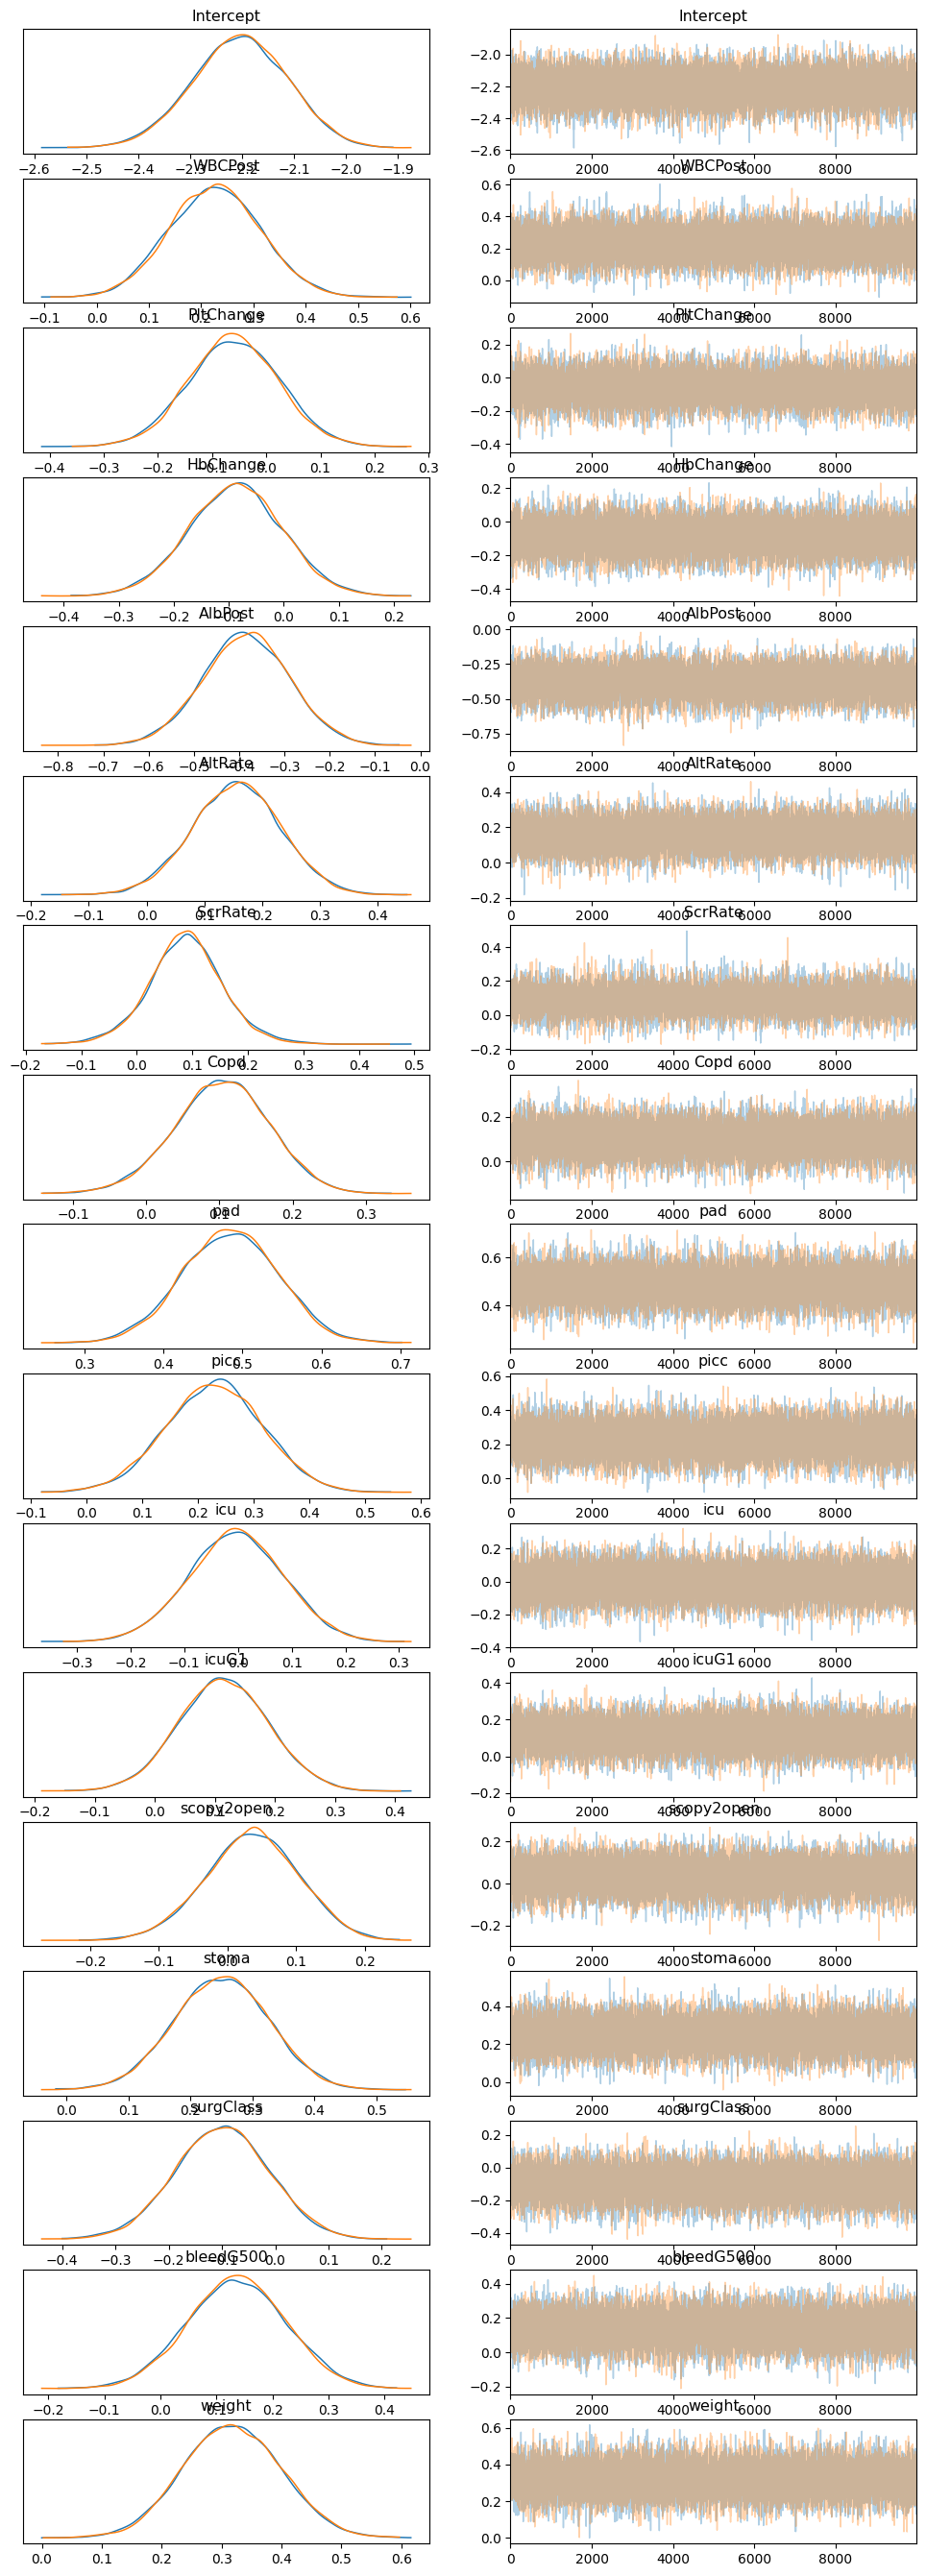

In [33]:
az.plot_trace(model_fitted, compact=False)

In [34]:
az.summary(model_fitted)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.205,0.092,-2.374,-2.031,0.000,0.000,35870.0,16988.0,1.0
WBCPost,0.227,0.088,0.060,0.388,0.000,0.000,39222.0,16066.0,1.0
PltChange,-0.060,0.083,-0.213,0.101,0.000,0.000,43056.0,14840.0,1.0
HbChange,-0.088,0.085,-0.250,0.072,0.000,0.000,32999.0,17186.0,1.0
AlbPost,-0.384,0.095,-0.565,-0.205,0.001,0.000,34272.0,16233.0,1.0
AltRate,0.156,0.077,0.016,0.304,0.000,0.000,36697.0,15376.0,1.0
ScrRate,0.089,0.068,-0.038,0.223,0.000,0.000,36978.0,14292.0,1.0
Copd,0.103,0.065,-0.018,0.225,0.000,0.000,42896.0,15307.0,1.0
pad,0.485,0.061,0.371,0.599,0.000,0.000,38069.0,16503.0,1.0
picc,0.229,0.087,0.066,0.392,0.000,0.000,33649.0,16897.0,1.0


## Model assessment

In [35]:
model.predict(model_fitted, kind="pps")
train_osssi_posterior = az.extract(model_fitted, num_samples=2000)["osssi_mean"]
print(train_osssi_posterior.shape)
train_osssi_posterior_mean = np.mean(train_osssi_posterior,axis=1)
print(train_osssi_posterior_mean.shape)

(1658, 2000)


In [37]:
model.predict(model_fitted, data=test_data)
test_osssi_posterior = az.extract(model_fitted, num_samples=2000)["osssi_mean"]
print(test_osssi_posterior.shape)
test_osssi_posterior_mean = np.mean(test_osssi_posterior,axis=1)
print(test_osssi_posterior_mean.shape)

(711, 2000)
(711,)


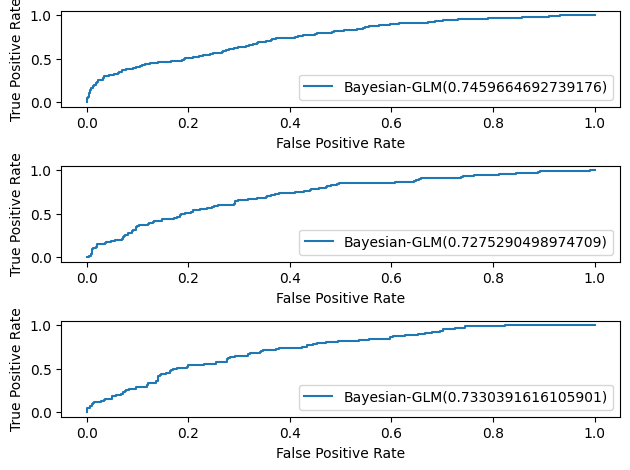

In [40]:
l_label = "Bayesian-GLM"
labels = train_labels
scores = train_osssi_posterior_mean

score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.subplot(3,1,1)
plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()


labels = test_labels
scores = test_osssi_posterior_mean

score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.subplot(3,1,2)
plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()
plt.tight_layout()
# plt.savefig("/kaggle/working/glm.jpg")